In [1]:
import numpy as np
import pandas as pd


In [2]:
df_public=pd.read_csv("/content/survey_results_public.csv")

/tmp/ipykernel_2539/4087558340.py:1: DtypeWarning: Columns (28,39,56,97,98,105,115,116,132,161,163,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df_public=pd.read_csv("/content/survey_results_public.csv")


In [266]:
df_public.shape

(16423, 172)

    QUICK REFERENCE: Salary Prediction Model
    =========================================
    
    TARGET VARIABLE:
    - ConvertedCompYearly (Annual salary in USD)
    
    DATASET STATS:
    - Total Records: 49,191
    - Records with Salary: 23,947 (48.7%)
    - Salary Range: $1 to $50M (contains outliers)
    - Median Salary: $75,320
    - Mean Salary: $101,762
    
    ===============================================================================
    TOP FEATURES TO USE (Ranked by Importance)
    ===============================================================================
    
    TIER 1 - CRITICAL FEATURES (Must Include):
    -------------------------------------------
    1. Country                    - 177 countries, huge salary variance by location
    2. WorkExp                    - Years of professional work experience
    3. YearsCode                  - Total years coding experience
    4. DevType                    - Job role (Backend, Frontend, Manager, etc.)
    5. EdLevel                    - Education level (Bachelor's, Master's, etc.)
    
    TIER 2 - IMPORTANT FEATURES (Highly Recommended):
    --------------------------------------------------
    6. OrgSize                    - Company size (correlates with salary)
    7. Age                        - Age group (7 categories)
    8. Industry                   - Industry sector (Fintech pays more)
    9. RemoteWork                 - Remote/Hybrid/In-person work arrangement
    10. Employment                - Employment type (Full-time, Contractor, etc.)
    
    TIER 3 - TECHNICAL SKILLS (Medium Importance):
    -----------------------------------------------
    11. LanguageHaveWorkedWith    - Programming languages (semicolon-separated)
    12. DatabaseHaveWorkedWith    - Database technologies used
    13. PlatformHaveWorkedWith    - Platforms (AWS, Azure, GCP, etc.)
    14. WebframeHaveWorkedWith    - Web frameworks (React, Vue, Angular, etc.)
    
    TIER 4 - SUPPLEMENTARY (Lower Importance):
    -------------------------------------------
    15. MainBranch                - Professional developer vs hobbyist
    16. ICorPM                    - Individual Contributor vs People Manager
    17. AISelect                  - AI tool usage
    18. AIToolCurrently*          - Current AI adoption level

In [246]:
df_public["ConvertedCompYearly"].median()

81210.0

In [159]:
df_public.columns

Index(['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment',
       'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode',
       'LearnCodeAI',
       ...
       'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure',
       'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 'AIHuman',
       'AIOpen', 'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=172)

**Exploratory Data Analysis**

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns


In [233]:
df_public["LanguageHaveWorkedWith"].unique()

array(['Bash/Shell (all shells);Dart;SQL', 'Java',
       'Dart;HTML/CSS;JavaScript;TypeScript', ...,
       'C;C#;C++;Java;MATLAB;Python',
       'Bash/Shell (all shells);Delphi;Go;HTML/CSS;Python;SQL;TypeScript',
       'Groovy;HTML/CSS;Java;JavaScript;SQL;TypeScript'], dtype=object)

In [193]:
# 1. Load and Basic Filter
df = pd.read_csv('/content/survey_results_public.csv', low_memory=False)
df_eda = df[df['ConvertedCompYearly'].notna()].copy()
# Remove extreme outliers for clearer visualization
df_eda = df_eda[(df_eda['ConvertedCompYearly'] >= 5000) & (df_eda['ConvertedCompYearly'] <= 500000)]

In [198]:
# 2. Tier 1 & 2: Experience & Age Numerical Conversion
def clean_years(x):
    if pd.isna(x): return np.nan
    if x == 'More than 50 years': return 51
    if x == 'Less than 1 year': return 0.5
    return float(x)

df_eda['YearsCode'] = df_eda['YearsCode'].apply(clean_years)
df_eda['WorkExp'] = pd.to_numeric(df_eda['WorkExp'], errors='coerce')
age_map = {'18-24 years old': 21, '25-34 years old': 29.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '55-64 years old': 59.5, '65 years or older': 70, 'Under 18 years old': 15}
df_eda['Age_Numeric'] = df_eda['Age'].map(age_map)


Text(0.5, 1.0, 'Distribution of Annual Compensation (Filtered $5k-$500k)')

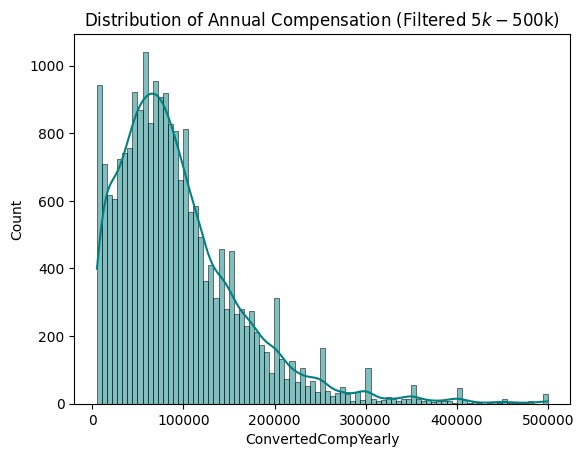

In [204]:
# A. Salary Distribution

sns.histplot(df_eda['ConvertedCompYearly'], kde=True, color='teal')
plt.title('Distribution of Annual Compensation (Filtered $5k-$500k)')


/tmp/ipykernel_2539/1608073733.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


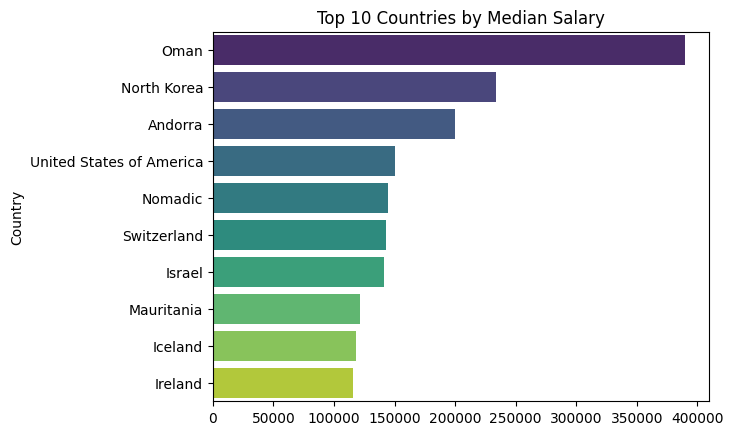

In [209]:
# B. Tier 1: Top 10 Countries by Median Salary

top_countries = df_eda.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Median Salary')
plt.show()

Text(0.5, 1.0, 'Correlation: Compensation vs Experience/Age')

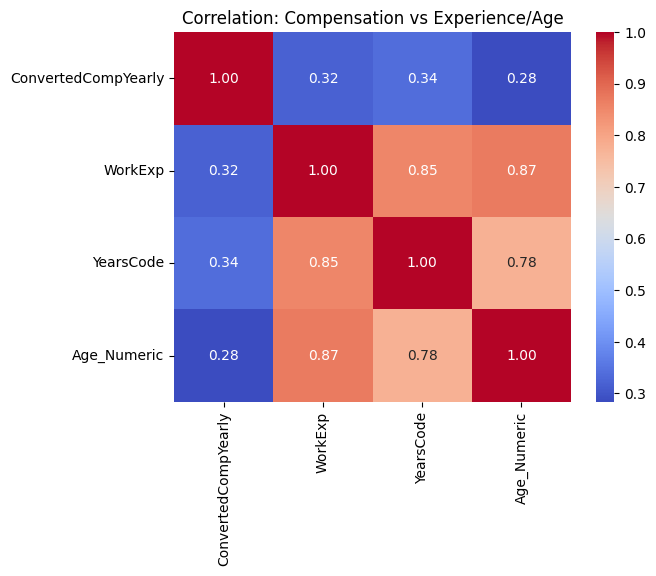

In [202]:
# C. Tier 1/2: Experience vs Salary (Heatmap Correlation)

corr = df_eda[['ConvertedCompYearly', 'WorkExp', 'YearsCode', 'Age_Numeric']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Compensation vs Experience/Age')

/tmp/ipykernel_2539/1062955591.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='ConvertedCompYearly', y='OrgSize', order=org_order, palette='Set2')


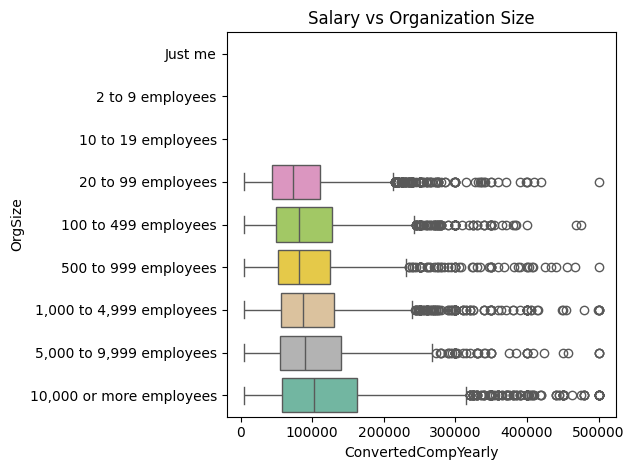

In [205]:
# D. Tier 2: OrgSize vs Salary

org_order = ['Just me', '2 to 9 employees', '10 to 19 employees', '20 to 99 employees',
             '100 to 499 employees', '500 to 999 employees', '1,000 to 4,999 employees',
             '5,000 to 9,999 employees', '10,000 or more employees']
sns.boxplot(data=df_eda, x='ConvertedCompYearly', y='OrgSize', order=org_order, palette='Set2')
plt.title('Salary vs Organization Size')

plt.tight_layout()
plt.show()

In [206]:
# E. Tier 3: Technical Skills Analysis (Languages)
print("Tier 3 - Top 10 Highest Paying Languages (Median):")
langs = df_eda['LanguageHaveWorkedWith'].str.get_dummies(sep=';')
lang_salaries = {col: df_eda[langs[col] == 1]['ConvertedCompYearly'].median() for col in langs.columns}
paying_langs = pd.Series(lang_salaries).sort_values(ascending=False).head(10)
print(paying_langs)

Tier 3 - Top 10 Highest Paying Languages (Median):
Ruby      106190.0
Erlang    104413.0
Scala     104413.0
Elixir    101437.0
Perl      100500.0
Swift      94712.0
Lisp       93312.0
Groovy     92812.0
Go         92812.0
Gleam      88430.0
dtype: float64


In [239]:
def get_top_paying_skills(df, column_name, top_n=10):
    # Expand multi-label column into dummies
    dummies = df[column_name].str.get_dummies(sep=';')
    # Calculate median salary for each technology
    salaries = {col: df[dummies[col] == 1]['ConvertedCompYearly'].median() for col in dummies.columns}
    return pd.Series(salaries).sort_values(ascending=False).head(top_n)

# Analyze Technologies
top_languages = get_top_paying_skills(df_eda, 'LanguageHaveWorkedWith')
top_databases = get_top_paying_skills(df_eda, 'DatabaseHaveWorkedWith')
top_platforms = get_top_paying_skills(df_eda, 'PlatformHaveWorkedWith')
top_webframes = get_top_paying_skills(df_eda, 'WebframeHaveWorkedWith')



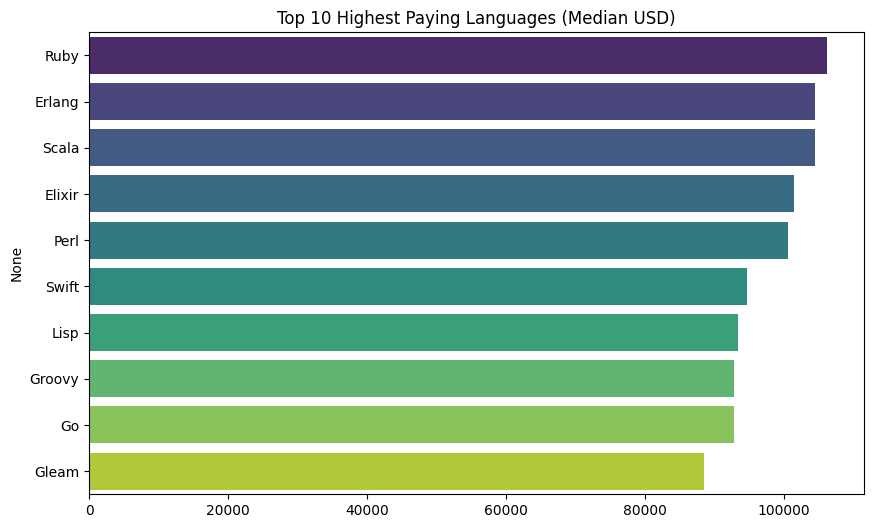

In [235]:
# Top 10 Highest Paying Languages
plt.figure(figsize=(10, 6))
sns.barplot(x=top_languages.values, y=top_languages.index, hue=top_languages.index, palette='viridis', legend=False)
plt.title('Top 10 Highest Paying Languages (Median USD)')
plt.show()

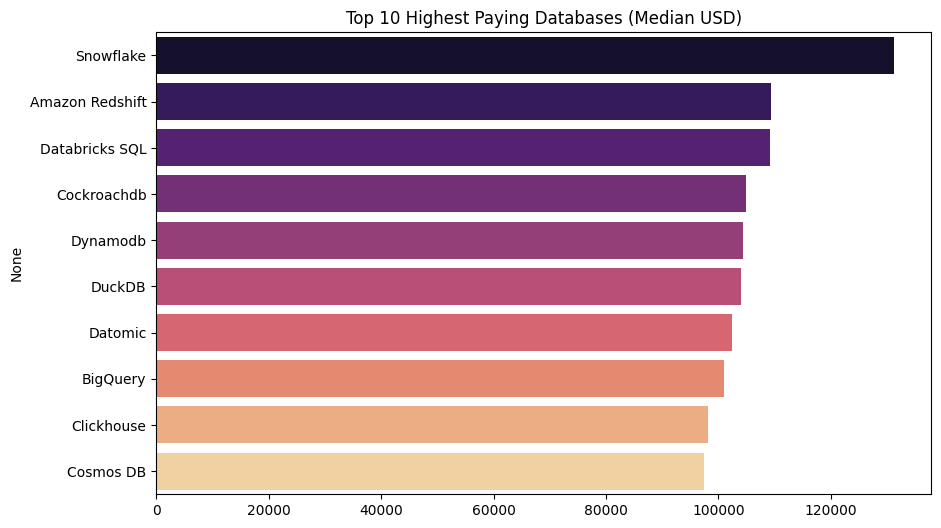

In [236]:
# Top 10 Highest Paying Databases
plt.figure(figsize=(10, 6))
sns.barplot(x=top_databases.values, y=top_databases.index, hue=top_databases.index, palette='magma', legend=False)
plt.title('Top 10 Highest Paying Databases (Median USD)')
plt.show()

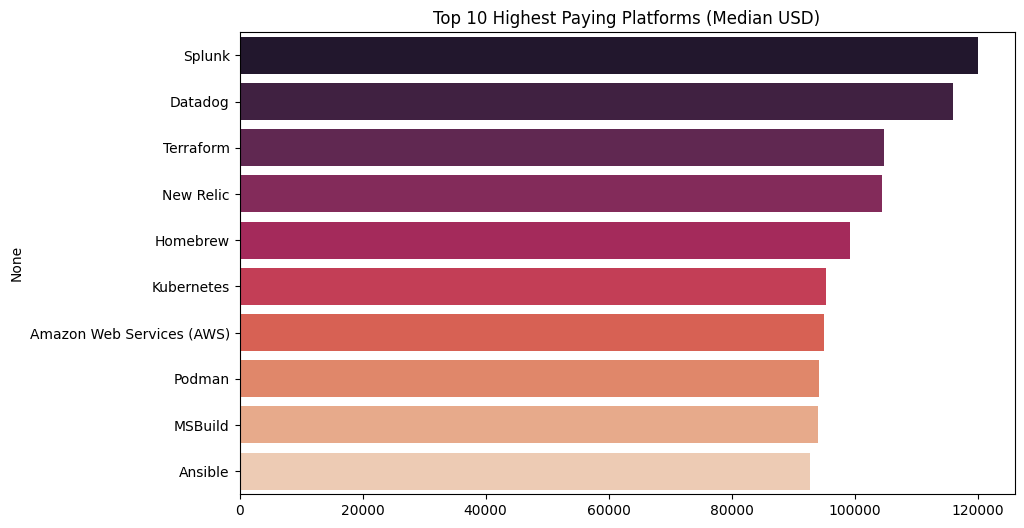

In [237]:
# Top 10 Highest Paying Platforms
plt.figure(figsize=(10, 6))
sns.barplot(x=top_platforms.values, y=top_platforms.index, hue=top_platforms.index, palette='rocket', legend=False)
plt.title('Top 10 Highest Paying Platforms (Median USD)')
plt.show()

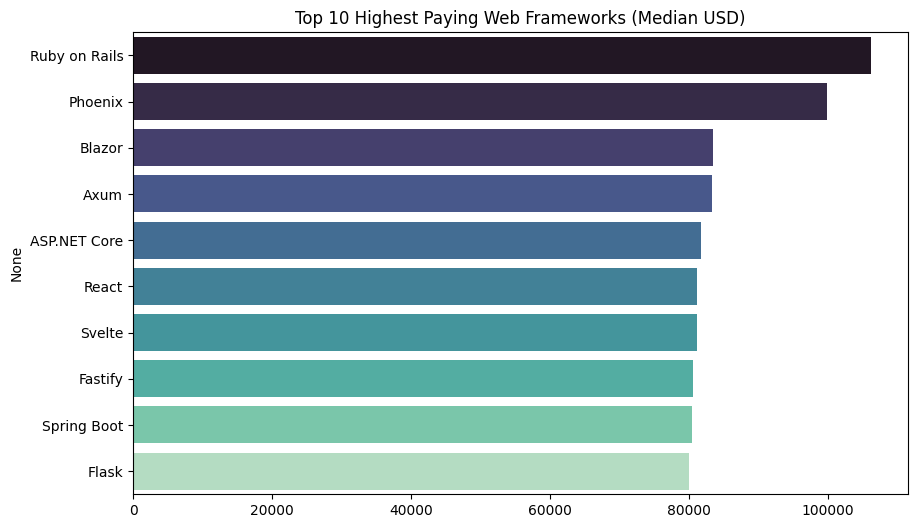

In [238]:
# Top 10 Highest Paying Web Frameworks
plt.figure(figsize=(10, 6))
sns.barplot(x=top_webframes.values, y=top_webframes.index, hue=top_webframes.index, palette='mako', legend=False)
plt.title('Top 10 Highest Paying Web Frameworks (Median USD)')
plt.show()

Tier 4: Supplementary Features Analysis

In this section, we analyze the impact of professional role types (Individual Contributor vs Manager), AI tool usage, and general developer status on compensation.

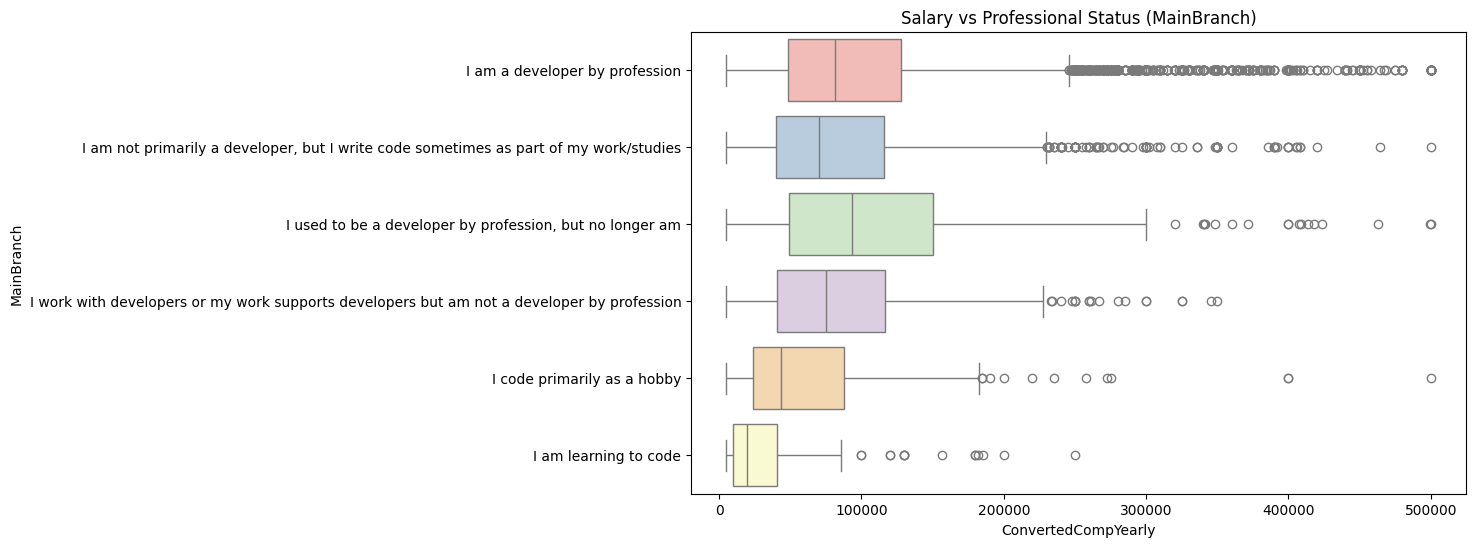

In [240]:
# 1. Professional Status (MainBranch) vs Salary
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eda, x='ConvertedCompYearly', y='MainBranch', palette='Pastel1', hue='MainBranch', legend=False)
plt.title('Salary vs Professional Status (MainBranch)')
plt.show()

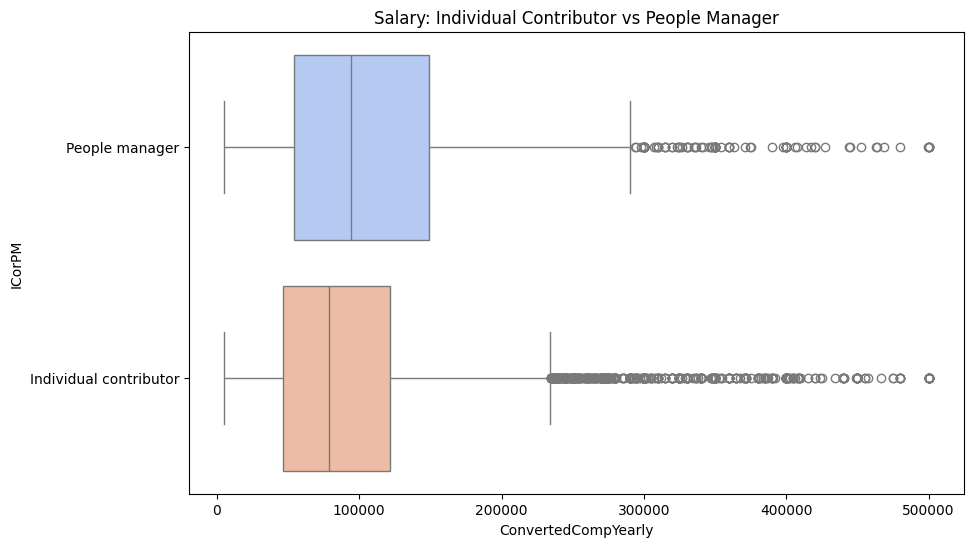

In [241]:
# 2. Individual Contributor vs People Manager (ICorPM) vs Salary
# Note: This column might have many NaN values if only specific roles were asked.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eda[df_eda['ICorPM'].notna()], x='ConvertedCompYearly', y='ICorPM', palette='coolwarm', hue='ICorPM', legend=False)
plt.title('Salary: Individual Contributor vs People Manager')
plt.show()

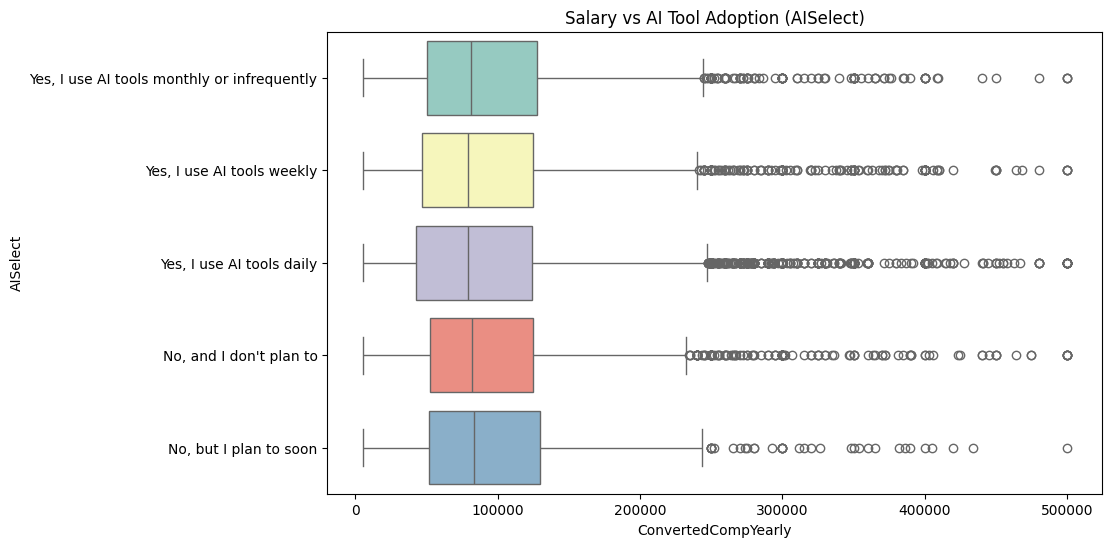

In [242]:
# 3. AI Tool Usage (AISelect) vs Salary
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eda[df_eda['AISelect'].notna()], x='ConvertedCompYearly', y='AISelect', palette='Set3', hue='AISelect', legend=False)
plt.title('Salary vs AI Tool Adoption (AISelect)')
plt.show()

**Feature Engineering**

In [247]:
# Feature Engineering: One-Hot Encoding for Tier 1-4 data

# 1. Define columns for simple dummy encoding
cat_cols = ['Country', 'EdLevel', 'OrgSize', 'RemoteWork', 'Employment', 'MainBranch', 'ICorPM', 'AISelect']

# Filter df_eda to keep only necessary columns for the model to save memory
model_features = cat_cols + ['YearsCode', 'WorkExp', 'Age_Numeric', 'ConvertedCompYearly', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'DevType']
df_model = df_eda[model_features].dropna(subset=['ConvertedCompYearly']).copy()

# 2. Get dummies for single-choice categorical columns
df_final = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# 3. Handle Multi-select columns (Tier 3 Tech Stack + DevType)
multi_select_cols = ['LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'DevType']

for col in multi_select_cols:
    dummies = df_final[col].str.get_dummies(sep=';')
    # Prefix names to avoid collisions
    dummies.columns = [f"{col}_{c}" for c in dummies.columns]
    df_final = pd.concat([df_final, dummies], axis=1)
    df_final.drop(col, axis=1, inplace=True)

print(f"Feature engineering complete. New shape: {df_final.shape}")
df_final.head()

Feature engineering complete. New shape: (22060, 367)


,YearsCode,WorkExp,Age_Numeric,ConvertedCompYearly,Country_Albania,Country_Algeria,Country_Andorra,Country_Angola,Country_Argentina,Country_Armenia,...,"DevType_Founder, technology or otherwise",DevType_Other (please specify):,DevType_Product manager,DevType_Project manager,DevType_Retired,"DevType_Senior executive (C-suite, VP, etc.)",DevType_Student,DevType_Support engineer or analyst,DevType_System administrator,"DevType_UX, Research Ops or UI design professional"
0,14.0,8.0,29.5,61256.0,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,10.0,2.0,29.5,104413.0,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,12.0,10.0,39.5,53061.0,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,5.0,4.0,39.5,36197.0,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,22.0,21.0,39.5,60000.0,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [248]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Prepare features and target
X = df_final.drop('ConvertedCompYearly', axis=1)
y = df_final['ConvertedCompYearly']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit Random Forest (using a subset of trees for speed in analysis)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Display top 20 drivers
display(feature_importance_df.head(20))

,Feature,Importance
150,Country_United States of America,0.244243
1,WorkExp,0.128706
0,YearsCode,0.047202
165,"OrgSize_10,000 or more employees",0.017754
136,Country_Switzerland,0.016525
148,Country_United Kingdom of Great Britain and No...,0.010810
2,Age_Numeric,0.009729
298,PlatformHaveWorkedWith_Terraform,0.008848
265,PlatformHaveWorkedWith_Amazon Web Services (AWS),0.007846
178,"Employment_Independent contractor, freelancer,...",0.007777


/tmp/ipykernel_2539/1335923612.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='magma')


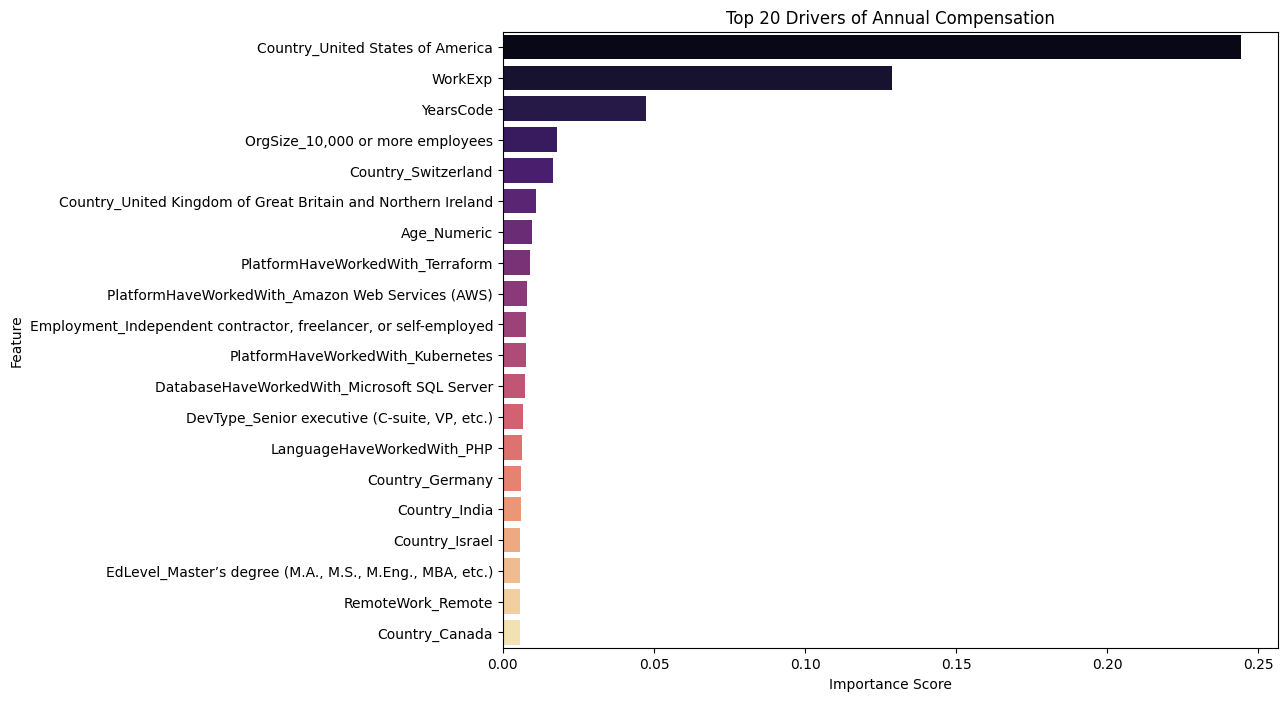

In [249]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='magma')
plt.title('Top 20 Drivers of Annual Compensation')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

**Building A Model**

XG Boost

In [270]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# Defining the 18 features across the 4 tiers
requested_features = [
    'Country', 'WorkExp', 'YearsCode', 'DevType', 'EdLevel',
    'OrgSize', 'Age_Numeric', 'Industry', 'RemoteWork', 'Employment',
    'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith', 'MainBranch', 'ICorPM', 'AISelect', 'AIToolCurrently'
]

# Identify columns in the processed df_final that match these 18 features
# Note: Industry and AIToolCurrently were handled in multi-select or categorical encoding
final_feature_cols = []
for col in df_final.columns:
    if any(col.startswith(feat) for feat in requested_features) or col in ['YearsCode', 'WorkExp', 'Age_Numeric']:
        if col != 'ConvertedCompYearly':
            final_feature_cols.append(col)

print(f"Training with {len(final_feature_cols)} encoded columns derived from the 18 features.")

# Split data using ONLY these features
X_curated = df_final[final_feature_cols]
y_curated = df_final['ConvertedCompYearly']

X_train_cur, X_test_cur, y_train_cur, y_test_cur = train_test_split(X_curated, y_curated, test_size=0.2, random_state=42)

# Initialize XGBoost
xgb_final = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Fit Model
xgb_final.fit(X_train_cur, y_train_cur)

# Predict and Evaluate
y_pred_final = xgb_final.predict(X_test_cur)
r2_final = r2_score(y_test_cur, y_pred_final)
mae_final = mean_absolute_error(y_test_cur, y_pred_final)

print(f"\nModel Performance (18 Features):")
print(f"R^2 Score: {r2_final:.4f}")
print(f"Mean Absolute Error: ${mae_final:,.2f}")

Training with 366 encoded columns derived from the 18 features.

Model Performance (18 Features):
R^2 Score: 0.5558
Mean Absolute Error: $29,604.25


In [272]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# Define the parameter grid for tuning
param_dist = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

# Initialize the XGBRegressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Set up Randomized Search
# n_iter=10 for a balance between speed and optimization quality
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist,
    n_iter=10,
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the search
print("Starting Hyperparameter Tuning (Randomized Search)...")
xgb_random_search.fit(X_train_cur, y_train_cur)

# Results
print(f"Best Parameters: {xgb_random_search.best_params_}")
print(f"Best R2 Score from CV: {xgb_random_search.best_score_:.4f}")

# Evaluate on Test Set
best_xgb = xgb_random_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_cur)
print(f"Tuned Model Test R2: {r2_score(y_test_cur, y_pred_tuned):.4f}")

Starting Hyperparameter Tuning (Randomized Search)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.7}
Best R2 Score from CV: 0.5676
Tuned Model Test R2: 0.5579


In [277]:
import lightgbm as lgb
import re
from sklearn.metrics import r2_score

# LightGBM doesn't like special JSON characters in feature names
def clean_col_names(df):
    df.columns = [re.sub(r'[\:\"\{\}\[\]\,]', '', col) for col in df.columns]
    return df

# Create sanitized copies of the curated features
X_train_lgb = clean_col_names(X_train_cur.copy())
X_test_lgb = clean_col_names(X_test_cur.copy())

# Initialize and train a single LightGBM model
print("Training LightGBM model...")
lgbm_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train_lgb, y_train_cur)

# Predict and Evaluate
y_pred_lgbm = lgbm_model.predict(X_test_lgb)
r2_lgbm = r2_score(y_test_cur, y_pred_lgbm)

print(f"LightGBM Test R2: {r2_lgbm:.4f}")

Training LightGBM model...
LightGBM Test R2: 0.5521


In [278]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize CatBoost
# Using standard parameters for a quick and reliable baseline
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

print("Training CatBoost model...")
cat_model.fit(X_train_cur, y_train_cur)

# Predict and Evaluate
y_pred_cat = cat_model.predict(X_test_cur)
r2_cat = r2_score(y_test_cur, y_pred_cat)
mae_cat = mean_absolute_error(y_test_cur, y_pred_cat)

print(f"\nCatBoost Performance:")
print(f"R^2 Score: {r2_cat:.4f}")
print(f"Mean Absolute Error: ${mae_cat:,.2f}")

Training CatBoost model...
0:	learn: 69183.8909726	total: 13.7ms	remaining: 13.7s
100:	learn: 49198.4242874	total: 1.19s	remaining: 10.6s
200:	learn: 46917.0882070	total: 2.31s	remaining: 9.18s
300:	learn: 45350.9599320	total: 3.43s	remaining: 7.97s
400:	learn: 44165.5943352	total: 4.56s	remaining: 6.81s
500:	learn: 43179.5739526	total: 5.69s	remaining: 5.66s
600:	learn: 42341.4712987	total: 7.54s	remaining: 5s
700:	learn: 41564.6553005	total: 8.68s	remaining: 3.7s
800:	learn: 40867.8527732	total: 10.1s	remaining: 2.51s
900:	learn: 40250.4931010	total: 12.4s	remaining: 1.36s
999:	learn: 39695.0300223	total: 13.7s	remaining: 0us

CatBoost Performance:
R^2 Score: 0.5537
Mean Absolute Error: $29,770.82


Hyperparameter Tuning: LightGBM & CatBoost (Randomized Search)

In [279]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
from catboost import CatBoostRegressor

# 1. LightGBM Tuning
lgb_reg = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
lgb_param_dist = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'feature_fraction': [0.7, 0.8, 0.9],
    'bagging_fraction': [0.7, 0.8, 0.9],
    'min_child_samples': [10, 20, 50]
}

lgb_random_search = RandomizedSearchCV(
    estimator=lgb_reg,
    param_distributions=lgb_param_dist,
    n_iter=10,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)

print("Starting LightGBM Randomized Search...")
lgb_random_search.fit(X_train_lgb, y_train_cur)
print(f"LGBM Best Params: {lgb_random_search.best_params_}")
print(f"LGBM Tuned R2: {r2_score(y_test_cur, lgb_random_search.best_estimator_.predict(X_test_lgb)):.4f}")

# 2. CatBoost Tuning
cat_reg = CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0)
cat_param_dist = {
    'iterations': [500, 1000],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128]
}

cat_random_search = RandomizedSearchCV(
    estimator=cat_reg,
    param_distributions=cat_param_dist,
    n_iter=10,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)

print("\nStarting CatBoost Randomized Search...")
cat_random_search.fit(X_train_cur, y_train_cur)
print(f"CatBoost Best Params: {cat_random_search.best_params_}")
print(f"CatBoost Tuned R2: {r2_score(y_test_cur, cat_random_search.best_estimator_.predict(X_test_cur)):.4f}")

Starting LightGBM Randomized Search...
LGBM Best Params: {'num_leaves': 127, 'n_estimators': 1000, 'min_child_samples': 50, 'learning_rate': 0.01, 'feature_fraction': 0.7, 'bagging_fraction': 0.8}
LGBM Tuned R2: 0.5518

Starting CatBoost Randomized Search...
CatBoost Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 8, 'border_count': 32}
CatBoost Tuned R2: 0.5596


 Final Model Performance Comparison (Tuned Models)

In [280]:
import pandas as pd

# Collect results from the tuning objects
results_data = {
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'Tuning Method': ['Randomized Search', 'Randomized Search', 'Randomized Search'],
    'Test R2 Score': [
        r2_score(y_test_cur, xgb_random_search.best_estimator_.predict(X_test_cur)),
        r2_score(y_test_cur, lgb_random_search.best_estimator_.predict(X_test_lgb)),
        r2_score(y_test_cur, cat_random_search.best_estimator_.predict(X_test_cur))
    ],
    'Best Parameters': [
        str(xgb_random_search.best_params_),
        str(lgb_random_search.best_params_),
        str(cat_random_search.best_params_)
    ]
}

comparison_df = pd.DataFrame(results_data).sort_values(by='Test R2 Score', ascending=False)
display(comparison_df)

,Model,Tuning Method,Test R2 Score,Best Parameters
2,CatBoost,Randomized Search,0.559591,"{'learning_rate': 0.05, 'l2_leaf_reg': 3, 'ite..."
0,XGBoost,Randomized Search,0.557882,"{'subsample': 0.8, 'n_estimators': 500, 'max_d..."
1,LightGBM,Randomized Search,0.551840,"{'num_leaves': 127, 'n_estimators': 1000, 'min..."


 Attempting to improve performance through Model Stacking

We combine our tuned models into a `StackingRegressor` to see if the ensemble can outperform individual models.

In [283]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Define the base models using the best params found earlier
estimators = [
    ('xgb', xgb_random_search.best_estimator_),
    ('cat', cat_random_search.best_estimator_),
    ('lgbm', lgb_random_search.best_estimator_)
]

# Initialize Stacking Regressor
# Using RidgeCV as the final estimator to prevent overfitting at the meta-level
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1
)

print("Training Stacking Regressor (this may take a few minutes)...")
stack_model.fit(X_train_lgb, y_train_cur)

# Evaluate
y_pred_stack = stack_model.predict(X_test_lgb)
r2_stack = r2_score(y_test_cur, y_pred_stack)
mae_stack = mean_absolute_error(y_test_cur, y_pred_stack)

print(f"\nStacking Regressor Performance:")
print(f"R^2 Score: {r2_stack:.4f}")
print(f"Mean Absolute Error: ${mae_stack:,.2f}")

Training Stacking Regressor (this may take a few minutes)...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Stacking Regressor Performance:
R^2 Score: 0.5651
Mean Absolute Error: $29,195.45


Model Stability Analysis (Cross-Validation)

We will use 5-fold cross-validation to assess the stability of our top two models: CatBoost and XGBoost.

In [281]:
from sklearn.model_selection import cross_val_score

# 1. Cross-validation for Tuned CatBoost
print("Calculating Cross-Validation scores for CatBoost...")
cat_scores = cross_val_score(cat_random_search.best_estimator_, X_curated, y_curated, cv=5, scoring='r2', n_jobs=-1)

# 2. Cross-validation for Tuned XGBoost
print("Calculating Cross-Validation scores for XGBoost...")
xgb_scores = cross_val_score(xgb_random_search.best_estimator_, X_curated, y_curated, cv=5, scoring='r2', n_jobs=-1)

print(f"\nCatBoost CV R2 Scores: {cat_scores}")
print(f"CatBoost Mean R2: {cat_scores.mean():.4f} (+/- {cat_scores.std() * 2:.4f})")

print(f"\nXGBoost CV R2 Scores: {xgb_scores}")
print(f"XGBoost Mean R2: {xgb_scores.mean():.4f} (+/- {xgb_scores.std() * 2:.4f})")

Calculating Cross-Validation scores for CatBoost...
Calculating Cross-Validation scores for XGBoost...

CatBoost CV R2 Scores: [0.56260274 0.5740163  0.563345   0.58100375 0.5820577 ]
CatBoost Mean R2: 0.5726 (+/- 0.0167)

XGBoost CV R2 Scores: [0.55426964 0.57166781 0.55414081 0.57718058 0.57746282]
XGBoost Mean R2: 0.5669 (+/- 0.0212)


 Final Model Performance Leaderboard

Below is the consolidated performance of all tuned models and the final ensemble stacking model.

### Visualizing Model Performance: Actual vs. Predicted Salaries

This plot helps us visualize the relationship between the true salary values in our test set and the values predicted by our ensemble Stacking Regressor.

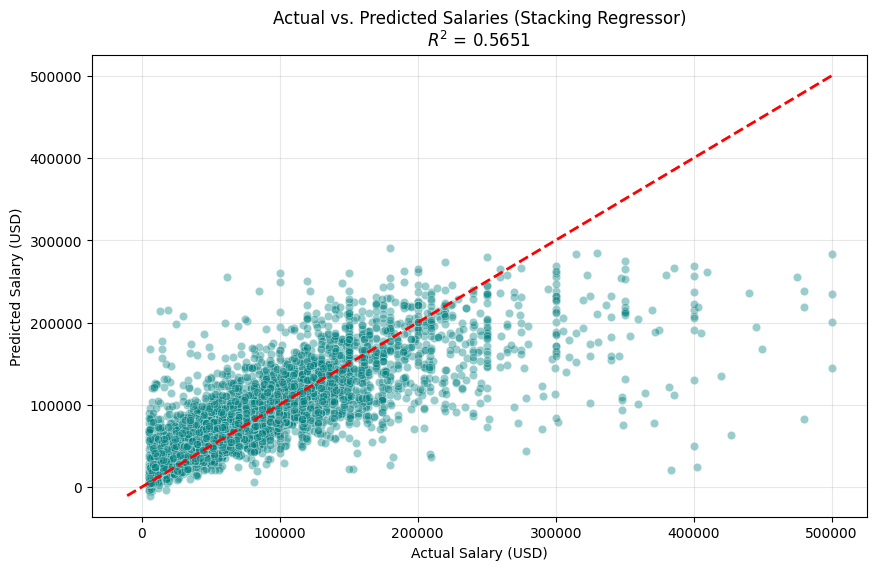

In [286]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Generate predictions using the ensemble model
y_pred_stack = stack_model.predict(X_test_lgb)

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_cur, y=y_pred_stack, alpha=0.4, color='teal')

# Add a line representing perfect prediction
max_val = max(y_test_cur.max(), y_pred_stack.max())
min_val = min(y_test_cur.min(), y_pred_stack.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')

plt.title(f'Actual vs. Predicted Salaries (Stacking Regressor)\n$R^2$ = {r2_score(y_test_cur, y_pred_stack):.4f}')
plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.grid(True, alpha=0.3)
plt.show()

In [284]:
import pandas as pd

# Calculate scores for the stacking model if not already stored
r2_stack_val = r2_score(y_test_cur, stack_model.predict(X_test_lgb))

# Create comparison table
leaderboard_data = {
    'Model Type': ['Stacking Regressor (Ensemble)', 'CatBoost (Tuned)', 'XGBoost (Tuned)', 'LightGBM (Tuned)'],
    'Test R2 Score': [
        r2_stack_val,
        r2_score(y_test_cur, cat_random_search.best_estimator_.predict(X_test_cur)),
        r2_score(y_test_cur, xgb_random_search.best_estimator_.predict(X_test_cur)),
        r2_score(y_test_cur, lgb_random_search.best_estimator_.predict(X_test_lgb))
    ]
}

leaderboard_df = pd.DataFrame(leaderboard_data).sort_values(by='Test R2 Score', ascending=False)
display(leaderboard_df.style.highlight_max(subset=['Test R2 Score'], color='lightgreen'))

,Model Type,Test R2 Score
0,Stacking Regressor (Ensemble),0.565116
1,CatBoost (Tuned),0.559591
2,XGBoost (Tuned),0.557882
3,LightGBM (Tuned),0.551840


**Interactive Salary Predictor**

Use the widgets below to input profile details and predict the estimated annual salary based on our trained Stacking Regressor.

In [285]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Get unique values for dropdowns from the encoded columns
countries = sorted([c.replace('Country_', '') for c in df_final.columns if c.startswith('Country_')])
ed_levels = sorted([e.replace('EdLevel_', '') for e in df_final.columns if e.startswith('EdLevel_')])
org_sizes = sorted([o.replace('OrgSize_', '') for o in df_final.columns if o.startswith('OrgSize_')])

# Widget UI
style = {'description_width': 'initial'}
exp_slider = widgets.IntSlider(value=5, min=0, max=50, description='Years of Experience:', style=style)
code_slider = widgets.IntSlider(value=7, min=0, max=50, description='Years of Coding:', style=style)
age_slider = widgets.FloatSlider(value=30, min=15, max=75, step=0.5, description='Age:', style=style)
country_dd = widgets.Dropdown(options=countries, value='United States of America', description='Country:', style=style)
ed_dd = widgets.Dropdown(options=ed_levels, description='Education Level:', style=style)
predict_btn = widgets.Button(description='Predict Salary', button_style='success')
output = widgets.Output()

def make_prediction(b):
    with output:
        clear_output()
        # Create a template row of zeros
        input_data = pd.DataFrame(0, index=[0], columns=X_curated.columns)

        # Fill numerical features
        input_data['WorkExp'] = float(exp_slider.value)
        input_data['YearsCode'] = float(code_slider.value)
        input_data['Age_Numeric'] = float(age_slider.value)

        # Fill categorical features
        if f'Country_{country_dd.value}' in input_data.columns: input_data[f'Country_{country_dd.value}'] = 1
        if f'EdLevel_{ed_dd.value}' in input_data.columns: input_data[f'EdLevel_{ed_dd.value}'] = 1

        # Align columns for LightGBM/Stacking requirement
        input_data_stack = clean_col_names(input_data.copy())

        prediction = stack_model.predict(input_data_stack)[0]
        print(f"Estimated Annual Salary: ${prediction:,.2f}")

predict_btn.on_click(make_prediction)

display(widgets.VBox([exp_slider, code_slider, age_slider, country_dd, ed_dd, predict_btn, output]))

In [290]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import re

# 1. Extract possible options. We manually add 'Individual contributor' back because it was dropped during encoding.
def get_options(prefix):
    return sorted([c.replace(f'{prefix}_', '') for c in X_curated.columns if c.startswith(f'{prefix}_')])

countries = get_options('Country')
ed_levels = get_options('EdLevel')
org_sizes = get_options('OrgSize')
remotework = get_options('RemoteWork')
employment = get_options('Employment')
mainbranch = get_options('MainBranch')
aiselect = get_options('AISelect')
devtypes = get_options('DevType')
languages = get_options('LanguageHaveWorkedWith')
databases = get_options('DatabaseHaveWorkedWith')
platforms = get_options('PlatformHaveWorkedWith')
webframes = get_options('WebframeHaveWorkedWith')

# Fix for ICorPM: We explicitly define the options since one was dropped
icorpm_options = ['Individual contributor', 'People manager']

# 2. Create Widgets
style = {'description_width': '150px'}
layout = widgets.Layout(width='500px')

exp_w = widgets.IntSlider(value=5, min=0, max=50, description='Work Experience:', style=style, layout=layout)
code_w = widgets.IntSlider(value=7, min=0, max=50, description='Years Coding:', style=style, layout=layout)
age_w = widgets.FloatSlider(value=30, min=15, max=75, step=0.5, description='Age:', style=style, layout=layout)

country_w = widgets.Dropdown(options=countries, value='United States of America', description='Country:', style=style, layout=layout)
ed_w = widgets.Dropdown(options=ed_levels, description='Education:', style=style, layout=layout)
org_w = widgets.Dropdown(options=org_sizes, description='Company Size:', style=style, layout=layout)
rem_w = widgets.Dropdown(options=remotework, description='Remote Work:', style=style, layout=layout)
emp_w = widgets.Dropdown(options=employment, description='Employment Type:', style=style, layout=layout)
branch_w = widgets.Dropdown(options=mainbranch, description='Main Branch:', style=style, layout=layout)
icpm_w = widgets.Dropdown(options=icorpm_options, value='Individual contributor', description='IC or Manager:', style=style, layout=layout)
ais_w = widgets.Dropdown(options=aiselect, description='AI Adoption:', style=style, layout=layout)

dev_w = widgets.SelectMultiple(options=devtypes, description='Dev Roles:', style=style, layout=widgets.Layout(width='500px', height='150px'))
lang_w = widgets.SelectMultiple(options=languages, description='Languages:', style=style, layout=widgets.Layout(width='500px', height='150px'))
db_w = widgets.SelectMultiple(options=databases, description='Databases:', style=style, layout=widgets.Layout(width='500px', height='150px'))
plat_w = widgets.SelectMultiple(options=platforms, description='Platforms:', style=style, layout=widgets.Layout(width='500px', height='150px'))
web_w = widgets.SelectMultiple(options=webframes, description='Web Frameworks:', style=style, layout=widgets.Layout(width='500px', height='150px'))

predict_btn = widgets.Button(description='Predict Salary', button_style='success', layout=widgets.Layout(width='200px', margin='20px 0 0 150px'))
output = widgets.Output()

def make_prediction(b):
    with output:
        clear_output()
        input_row = pd.DataFrame(0, index=[0], columns=X_curated.columns)

        input_row['WorkExp'] = float(exp_w.value)
        input_row['YearsCode'] = float(code_w.value)
        input_row['Age_Numeric'] = float(age_w.value)

        single_select_map = {
            'Country': country_w.value, 'EdLevel': ed_w.value, 'OrgSize': org_w.value,
            'RemoteWork': rem_w.value, 'Employment': emp_w.value, 'MainBranch': branch_w.value,
            'AISelect': ais_w.value
        }
        for feat, val in single_select_map.items():
            col_name = f"{feat}_{val}"
            if col_name in input_row.columns: input_row[col_name] = 1

        # Special logic for ICorPM due to drop_first=True
        if icpm_w.value == 'People manager':
            input_row['ICorPM_People manager'] = 1
        # If IC, the column stays 0 (the reference category)

        multi_select_map = {
            'DevType': dev_w.value, 'LanguageHaveWorkedWith': lang_w.value,
            'DatabaseHaveWorkedWith': db_w.value, 'PlatformHaveWorkedWith': plat_w.value,
            'WebframeHaveWorkedWith': web_w.value
        }
        for feat, selected_list in multi_select_map.items():
            for val in selected_list:
                col_name = f"{feat}_{val}"
                if col_name in input_row.columns: input_row[col_name] = 1

        input_ready = input_row.copy()
        input_ready.columns = [re.sub(r'[\:\"\{\}\[\]\,]', '', c) for c in input_ready.columns]

        pred = stack_model.predict(input_ready)[0]
        print(f"\nEstimated Annual Compensation: ${pred:,.2f} USD")

predict_btn.on_click(make_prediction)

ui = widgets.VBox([
    widgets.HTML("<h3>Advanced Salary Predictor</h3>"),
    widgets.HTML("<p><i>Note: Hold <b>Ctrl</b> or <b>Cmd</b> to select multiple tech options.</i></p>"),
    exp_w, code_w, age_w, country_w, ed_w, org_w, rem_w, emp_w, branch_w, icpm_w, ais_w,
    dev_w, lang_w, db_w, plat_w, web_w,
    predict_btn, output
])
display(ui)

In [291]:
import joblib
import json

# 1. Save the trained Stacking Regressor model
joblib.dump(stack_model, 'salary_stack_model.joblib')

# 2. Save the feature column names to ensure input alignment in the app
model_columns = X_curated.columns.tolist()
with open('model_columns.json', 'w') as f:
    json.dump(model_columns, f)

print("Deployment files ready!")
print("1. Download 'salary_stack_model.joblib'")
print("2. Download 'model_columns.json'")
print("\nYou can now use these in a Streamlit app to create a public web interface.")

Deployment files ready!
1. Download 'salary_stack_model.joblib'
2. Download 'model_columns.json'

You can now use these in a Streamlit app to create a public web interface.


In [295]:
import joblib
import pandas as pd
import numpy as np
import re

# Define the Streamlit app code as a string to write it to a file
# We use a raw f-string to handle regex backslashes and double braces for f-string literal braces
streamlit_app_code = f"""
import streamlit as st
import joblib
import pandas as pd
import numpy as np
import re

# 1. Hardcoded Feature List
MODEL_COLUMNS = {X_curated.columns.tolist()}

# 2. Helper function for sanitization
def clean_col_names(df):
    # Using a raw string for regex inside the generated code
    df.columns = [re.sub(r'[\\:\\"\\{{\\}}\\[\\]\\,]', '', col) for col in df.columns]
    return df

# 3. Load the Model
@st.cache_resource
def load_model():
    return joblib.load('salary_stack_model.joblib')

try:
    model = load_model()
except:
    st.error("Model file 'salary_stack_model.joblib' not found.")
    st.stop()

st.title("Advanced Salary Predictor (SO 2024)")

# UI Inputs
exp = st.slider("Years of Experience", 0, 50, 5)
code = st.slider("Years of Coding", 0, 50, 7)
age = st.number_input("Age", value=30.0)

countries = sorted([c.replace('Country_', '') for c in MODEL_COLUMNS if c.startswith('Country_')])
selected_country = st.selectbox("Country", countries, index=countries.index('United States of America') if 'United States of America' in countries else 0)

ed_levels = sorted([e.replace('EdLevel_', '') for e in MODEL_COLUMNS if e.startswith('EdLevel_')])
selected_ed = st.selectbox("Education Level", ed_levels)

if st.button("Predict Salary"):
    input_df = pd.DataFrame(0, index=[0], columns=MODEL_COLUMNS)
    input_df['WorkExp'] = float(exp)
    input_df['YearsCode'] = float(code)
    input_df['Age_Numeric'] = float(age)

    if f'Country_{{selected_country}}' in input_df.columns: input_df[f'Country_{{selected_country}}'] = 1
    if f'EdLevel_{{selected_ed}}' in input_df.columns: input_df[f'EdLevel_{{selected_ed}}'] = 1

    input_ready = clean_col_names(input_df.copy())
    prediction = model.predict(input_ready)[0]
    st.metric("Estimated Annual Salary", f"${{prediction:,.2f}} USD")
"""

with open('app.py', 'w') as f:
    f.write(streamlit_app_code)

print("Streamlit app script 'app.py' has been refreshed.")
print("Download 'app.py' and 'salary_stack_model.joblib' from the file pane.")

Streamlit app script 'app.py' has been refreshed.
Download 'app.py' and 'salary_stack_model.joblib' from the file pane.
